# 15.3 — EXTENDED TIMEFRAME COMPANION (static buy & hold only)

> ### THIS NOTEBOOK IS NOT THE TRIO. IT IS ONE LINE.
>
> Extended-timeframe companion to `15_2_tear_sheet_gallery.ipynb` and
> `18_final_trio_dashboard.ipynb`, on **separate datasets of its own**. It covers
> **2009-09-25 → 2026-05-29 (16.7 years)** and contains exactly one strategy: the
> static 25%-each buy-and-hold basket `SWDA.L / XLK / IAU / BIL`, bought once and
> never rebalanced.
>
> **The AI macro-factor line and the SJM×crowding de-risk line cannot appear here
> before 2019 — at all.** Their loadings and scores are outputs of an LLM
> (`openai/gpt-oss-20b` via NVIDIA NIM). Those outputs exist only for the 72
> replayed + 18 live rebalance dates of the 2019+ era, and the response cache
> (`.llm_cache_v2/cache.db`) holds exactly those, with **zero pre-2019 replies**.
> There is no earlier history to plot — only earlier history that was never
> scored. Reaching back to 2016 would take roughly 180 new live model calls, 2009
> several hundred more. Nothing here extrapolates those lines backwards, and a
> one-line long-window chart must not be read as the trio.
>
> `data/factor_equity_ext2026.parquet` does carry an index starting 2014-01-02,
> but its value is **flat** until the first rebalance on 2019-01-03. That stub is
> padding, not history — the self-check cell below verifies it rather than asking
> you to take it on trust.

Separate datasets, built by `scripts/build_static_bh_long.py` (a thin window
wrapper that imports `scripts/build_static_bh.py`'s construction rather than
re-implementing it):

| artifact | window | role |
|---|---|---|
| `data/static_bh_equity_2009_2026.parquet` | 2009-09-25 → 2026-05-29 | the long line (new) |
| `data/static_bh_equity_2019_2026.parquet` | 2019-01-02 → 2026-01-30 | fresh 2019 buy (new) |
| `data/static_bh_equity_2016_2026.parquet` | 2016-02-01 → 2026-01-30 | fresh 2016 buy (existing, untouched) |

Twenty years is not available: SWDA.L lists on 2009-09-25 and is the binding
constraint (BIL lists 2007-05, and the project's own price DB floors at 2010-01).
16.7 years is the longest line this basket admits.

Everything below reads those local parquets — **no network, no LLM, no
credentials**. Every metric comes from the shared
`macro_framework.evaluation.metric_block` and every stability verdict from
`macro_framework.ssr.ssr_inference`, the same authorities `15_2` and `18` use;
this notebook adds windows, never a private metric.

### Two caveats that more years do not fix

1. **In-sample by construction.** The four ETFs were selected by the Sharpe
   Stability Ratio computed over an overlapping window (nb02/nb03). A longer
   sample shows the same hindsight-selected basket over more history; it does not
   make the selection out-of-sample. The line is a hindsight artifact, not
   attainable skill.
2. **The risk-adjusted headline is substantially a function of starting in
   2019.** Sharpe decays monotonically as the window lengthens — **1.30** (7.1y)
   → **1.20** (10y) → **0.93** (16.4y) — with the same basket, the same
   construction and the same end date. Only the buy date moves.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "workbook"))

import pandas as pd
import matplotlib.pyplot as plt

# ONE metric convention for the whole repo — the same block nb15_2 / nb16 / nb17 /
# nb18 call, and the same SSR authority. This notebook contributes windows, not
# statistics: a private copy of either is how a companion notebook silently drifts
# off the published numbers.
from macro_framework.evaluation import metric_block
from macro_framework.ssr import ssr_inference

DATA = REPO / "data"
COMMON_END = "2026-01-30"   # the trio's end date — see the ladder note below

# Every rung is a FRESH BUY at its own start; only the hold is cut short, which is
# legitimate (same purchase, shorter holding period) where re-slicing a start is not.
LADDER = [
    ("static_bh_equity_2009_2026", "Full 16.7y (buy 2009)", None),
    ("static_bh_equity_2009_2026", "16.4y (buy 2009)", COMMON_END),
    ("static_bh_equity_2016_2026", "10.0y (buy 2016)", COMMON_END),
    ("static_bh_equity_2019_2026", "7.1y (buy 2019)", COMMON_END),
]

lines = {}
for stem, label, end in LADDER:
    v = pd.read_parquet(DATA / f"{stem}.parquet")["value"]
    lines[label] = v if end is None else v.loc[:end]

for label, v in lines.items():
    yrs = (v.index[-1] - v.index[0]).days / 365.25
    print(f"{label:<22s} {v.index.min():%Y-%m-%d} → {v.index.max():%Y-%m-%d}  "
          f"{len(v):>4d} rows  {yrs:5.2f}y")

Full 16.7y (buy 2009)  2009-09-25 → 2026-05-29  4116 rows  16.67y
16.4y (buy 2009)       2009-09-25 → 2026-01-30  4037 rows  16.35y
10.0y (buy 2016)       2016-02-01 → 2026-01-30  2469 rows  10.00y
7.1y (buy 2019)        2019-01-02 → 2026-01-30  1746 rows   7.08y


## Why every rung buys fresh instead of slicing the long line

Buy-and-hold holds **shares**, not weights. Slice the 2009 line at 2016 and you
inherit six and a half years of weight drift — by then the basket is no longer
25/25/25/25, it is whatever the winners compounded into — so the slice silently
answers a different question than "what would 25% each have done from 2016".
The size of the difference is not cosmetic: slicing the 2009 line to 2016–2026
reports CAGR 17.5% and max drawdown -24.2%, while buying fresh in 2016 reports
15.4% and -19.6%.

So each rung is a separate purchase at its own start date, and only the *end* is
cut to a common 2026-01-30 so the three comparable rungs share a horizon. The
first row keeps the full history to 2026-05-29 (the release pin) and is therefore
the only row with a different end.

In [2]:
def window_row(value: pd.Series, label: str) -> dict:
    """One tear-sheet row per window — a pure view over ``metric_block`` and
    ``ssr_inference``. Nothing is recomputed locally."""
    m = metric_block(value)
    inf = ssr_inference(m["returns"])
    trough = m["dd"].idxmin()
    return {
        "Label": label,
        "Start": value.index.min().date(), "End": value.index.max().date(),
        "Years (elapsed)": (value.index[-1] - value.index[0]).days / 365.25,
        "Number of days": len(m["returns"]),
        "Total Return": m["total_return"], "CAGR": m["cagr"],
        "Ann. Volatility": m["ann_vol"], "Sharpe": m["sharpe"],
        "Sortino": m["sortino"], "Max Drawdown": m["maxdd"], "Calmar": m["calmar"],
        "Max Drawdown Peak": value.loc[:trough].idxmax().date(),
        "Max Drawdown Trough": trough.date(),
        "SSR (Sharpe Stability Ratio)": inf.result.ssr,
        "SSR MBB p (one-sided)": inf.p_value,
        "SSR verdict": inf.verdict(),
    }


sheet = pd.DataFrame([window_row(v, lbl) for lbl, v in lines.items()]).set_index("Label")

TEAR = DATA / "tear_sheet"
TEAR.mkdir(exist_ok=True)
sheet.to_csv(TEAR / "tear_sheet_static_bh_windows.csv", float_format="%.8f")
sheet.to_csv(TEAR / "tear_sheet_static_bh_windows_de.csv", sep=";", decimal=",",
             float_format="%.8f")

sheet.drop(columns=["SSR verdict"]).style.format({
    "Years (elapsed)": "{:.2f}", "Total Return": "{:.1%}", "CAGR": "{:.1%}",
    "Ann. Volatility": "{:.1%}", "Sharpe": "{:.2f}", "Sortino": "{:.2f}",
    "Max Drawdown": "{:.1%}", "Calmar": "{:.2f}",
    "SSR (Sharpe Stability Ratio)": "{:.2f}", "SSR MBB p (one-sided)": "{:.3f}"})

,Start,End,Years (elapsed),Number of days,Total Return,CAGR,Ann. Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Max Drawdown Peak,Max Drawdown Trough,SSR (Sharpe Stability Ratio),SSR MBB p (one-sided)
Label,,,,,,,,,,,,,,,
Full 16.7y (buy 2009),2009-09-25,2026-05-29,16.67,4115,726.4%,13.5%,14.0%,0.99,1.41,-24.2%,0.56,2021-12-29,2022-10-14,0.12,0.000
16.4y (buy 2009),2009-09-25,2026-01-30,16.35,4036,580.4%,12.4%,13.8%,0.93,1.32,-24.2%,0.51,2021-12-29,2022-10-14,0.12,0.000
10.0y (buy 2016),2016-02-01,2026-01-30,10.00,2468,320.1%,15.4%,12.9%,1.20,1.73,-19.6%,0.79,2021-12-29,2022-10-14,0.15,0.000
7.1y (buy 2019),2019-01-02,2026-01-30,7.08,1745,208.4%,17.3%,13.2%,1.30,1.87,-17.8%,0.97,2021-12-29,2022-10-14,0.14,0.000


In [3]:
# Self-check — this cell exists to fail loudly. Three claims are pinned:
#   (1) METRIC PARITY. The released trio row "Static B&H 16-26" is the 2016 line
#       sliced to the trio window. Recomputing it here must reproduce the published
#       Sharpe to the CSV's %.8f floor — i.e. this companion is on the same
#       convention as the release, so nothing below is a re-based restatement.
#   (2) SLICE != FRESH BUY. That same 2019→2026 window, bought fresh, is a
#       materially different line. If this ever stopped being true, the ladder
#       could safely be built by slicing and the extra artifact would be dead code.
#   (3) NO PRE-2019 AI HISTORY. The header's central claim, verified rather than
#       asserted: both AI lines are flat until their first 2019 rebalance.
TOL = 5e-9  # == %.8f's half-ulp; bound is inclusive by design

trio = pd.read_csv(TEAR / "tear_sheet_trio_ext2026.csv").set_index("Label")
pub = trio.loc["Static B&H 16-26"]
sliced = metric_block(pd.read_parquet(DATA / "static_bh_equity_2016_2026.parquet")["value"]
                      .loc["2019-01-02":pub["End"]])
assert len(sliced["returns"]) == int(pub["Number of days"])
assert abs(sliced["sharpe"] - float(pub["Sharpe"])) <= TOL, (sliced["sharpe"], pub["Sharpe"])
print(f"(1) metric parity vs tear_sheet_trio_ext2026.csv: PASS "
      f"(Sharpe {sliced['sharpe']:.8f}, {len(sliced['returns'])} days)")

fresh = float(sheet.loc["7.1y (buy 2019)", "Sharpe"])
assert abs(fresh - sliced["sharpe"]) > 1e-3
print(f"(2) same 2019→2026 window — sliced from the 2016 buy: Sharpe "
      f"{sliced['sharpe']:.4f} / CAGR {sliced['cagr']:.4f}; bought fresh in 2019: "
      f"Sharpe {fresh:.4f} / CAGR {float(sheet.loc['7.1y (buy 2019)', 'CAGR']):.4f}")

for stem in ("factor_equity_ext2026", "sjm_crowding_derisk_v2_equity_ext2026"):
    v = pd.read_parquet(DATA / f"{stem}.parquet")["value"]
    first_move = v[v.ne(v.iloc[0])].index.min()
    padding = v.loc[:first_move].iloc[:-1]
    assert first_move >= pd.Timestamp("2019-01-01"), (stem, first_move)
    assert (padding == v.iloc[0]).all(), stem
    print(f"(3) {stem}: index from {v.index.min():%Y-%m-%d}, first move "
          f"{first_move:%Y-%m-%d}, {len(padding)} flat padding rows before it")

(1) metric parity vs tear_sheet_trio_ext2026.csv: PASS (Sharpe 1.23381874, 1745 days)
(2) same 2019→2026 window — sliced from the 2016 buy: Sharpe 1.2338 / CAGR 0.1809; bought fresh in 2019: Sharpe 1.2972 / CAGR 0.1725
(3) factor_equity_ext2026: index from 2014-01-02, first move 2019-01-03, 1239 flat padding rows before it
(3) sjm_crowding_derisk_v2_equity_ext2026: index from 2019-01-02, first move 2019-01-03, 1 flat padding rows before it


## The long line, and the region where the other two lines do not exist

Log scale, so equal vertical distances are equal percentage moves — on a 16.7-year
line a linear axis makes the last three years look like the whole story.

The **shaded region left of 2019-01-03 is the part of history the AI lines have
nothing to say about.** No LLM scores exist there, so no factor or de-risk line is
drawn there, and none should be inferred.

The 2020 (-22.8%) and 2022 (-24.2%, the line's worst) drawdowns in the unshaded
part are the same episodes the trio is evaluated on. What the shaded years add is
milder: the deepest pre-2019 episode is the Q4-2018 selloff at -14.6%, then 2010
at -10.4% and 2015 at -8.7%. That is the honest shape of the extra evidence — a
long, shallow decade, which is exactly why the annualized return holds up over
this window while the Sharpe does not.

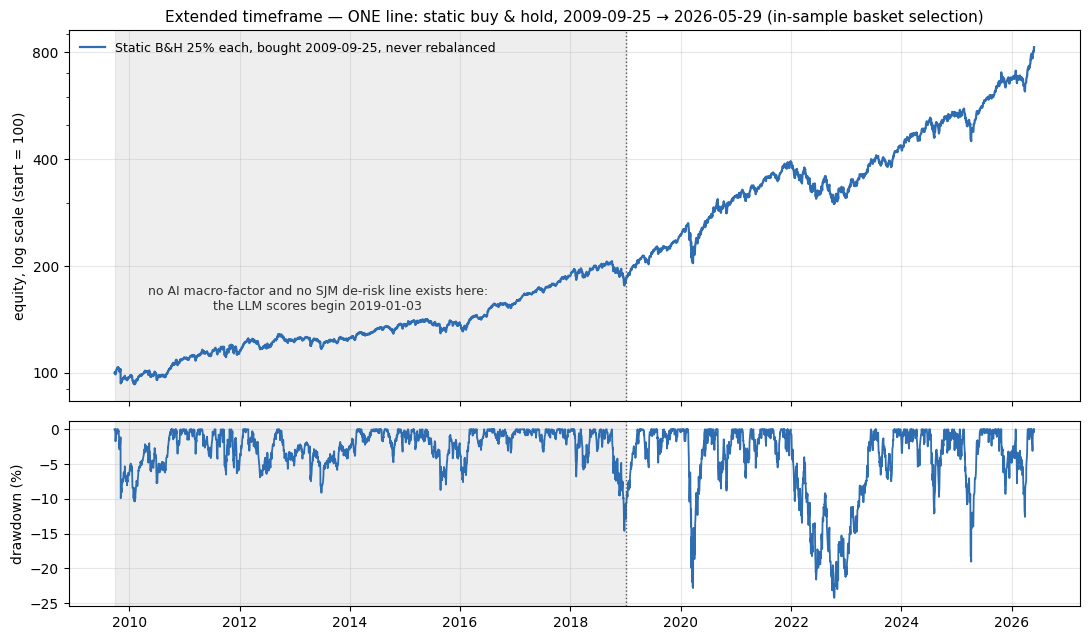

In [4]:
long = lines["Full 16.7y (buy 2009)"]
CUT = pd.Timestamp("2019-01-03")   # first AI-scored rebalance

fig, (ax_eq, ax_dd) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
ax_eq.plot(long.index, 100 * long / long.iloc[0], lw=1.6, color="#2f6db3",
           label="Static B&H 25% each, bought 2009-09-25, never rebalanced")
ax_eq.set_yscale("log")
ax_eq.set_yticks([100, 200, 400, 800])
ax_eq.set_yticklabels(["100", "200", "400", "800"])
ax_eq.set_ylabel("equity, log scale (start = 100)")
ax_eq.legend(frameon=False, fontsize=9, loc="upper left")

dd = long / long.cummax() - 1
ax_dd.plot(dd.index, 100 * dd, lw=1.3, color="#2f6db3")
ax_dd.set_ylabel("drawdown (%)")

for ax in (ax_eq, ax_dd):
    ax.axvspan(long.index.min(), CUT, color="#9a9a9a", alpha=0.16, zorder=0)
    ax.axvline(CUT, color="#555555", lw=1.0, ls=":")
    ax.grid(alpha=0.3)

ax_eq.annotate("no AI macro-factor and no SJM de-risk line exists here:\n"
               "the LLM scores begin 2019-01-03",
               xy=(pd.Timestamp("2013-06-01"), 150), fontsize=9, color="#333333",
               ha="center")
ax_eq.set_title("Extended timeframe — ONE line: static buy & hold, "
                f"{long.index.min():%Y-%m-%d} → {long.index.max():%Y-%m-%d} "
                "(in-sample basket selection)", fontsize=11)
fig.tight_layout()
fig.savefig(DATA / "nb15_3_long_window_equity.png", dpi=300, bbox_inches="tight")
plt.show()

## Sharpe against window length — the decay is the finding

Same basket, same construction, same 2026-01-30 end; only the buy date moves.
The risk-adjusted headline the trio reports is substantially a property of
starting in 2019, not a property of the basket.

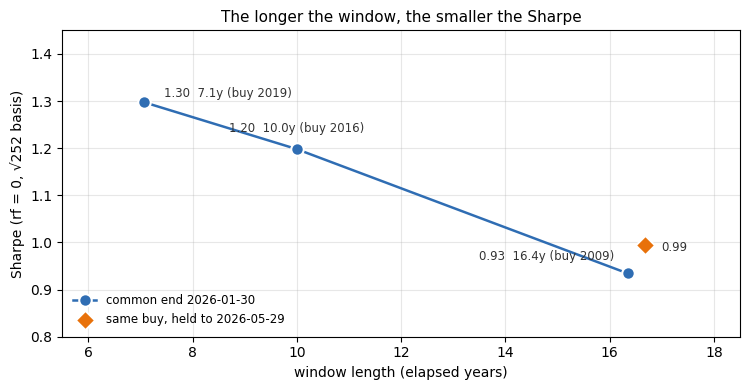

                       Years (elapsed)     CAGR  Ann. Volatility   Sharpe  Max Drawdown   Calmar  SSR (Sharpe Stability Ratio)
Label                                                                                                                         
Full 16.7y (buy 2009)          16.6735   0.1350           0.1400   0.9944       -0.2424   0.5570                        0.1199
16.4y (buy 2009)               16.3477   0.1245           0.1385   0.9343       -0.2424   0.5133                        0.1182
10.0y (buy 2016)                9.9959   0.1544           0.1293   1.1981       -0.1963   0.7865                        0.1472
7.1y (buy 2019)                 7.0773   0.1725           0.1322   1.2972       -0.1785   0.9666                        0.1448

Full 16.7y (buy 2009): SSR=0.12: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.000 < 0.05) — temporal consistency, not a skill claim

16.4y (buy 2009): SSR=0.12: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.0

In [5]:
rungs = sheet.loc[["7.1y (buy 2019)", "10.0y (buy 2016)", "16.4y (buy 2009)"]]

fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.plot(rungs["Years (elapsed)"], rungs["Sharpe"], "-o", color="#2f6db3", lw=1.8,
        ms=9, markeredgecolor="white", markeredgewidth=1.5, zorder=3,
        label=f"common end {COMMON_END}")
# per-point label slots: the 16.4y rung sits next to the full-length diamond, so its
# label goes LEFT — a shared "above, centered" slot collides with it and with the axes edge
SLOT = {"7.1y (buy 2019)": (14, 4, "left"), "10.0y (buy 2016)": (0, 12, "center"),
        "16.4y (buy 2009)": (-10, 10, "right")}
for lbl, row in rungs.iterrows():
    dx, dy, ha = SLOT[lbl]
    ax.annotate(f"{row['Sharpe']:.2f}  {lbl}", (row["Years (elapsed)"], row["Sharpe"]),
                xytext=(dx, dy), textcoords="offset points", ha=ha, fontsize=8.5,
                color="#333333")

full = sheet.loc["Full 16.7y (buy 2009)"]
ax.scatter(full["Years (elapsed)"], full["Sharpe"], s=95, marker="D", color="#e8710a",
           edgecolor="white", linewidth=1.4, zorder=3,
           label=f"same buy, held to {full['End']}")
ax.annotate(f"{full['Sharpe']:.2f}", (full["Years (elapsed)"], full["Sharpe"]),
            xytext=(12, -4), textcoords="offset points", ha="left", fontsize=8.5,
            color="#333333")

ax.set_xlabel("window length (elapsed years)")
ax.set_ylabel("Sharpe (rf = 0, √252 basis)")
ax.set_xlim(5.5, 18.5)
ax.set_ylim(0.80, 1.45)
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=8.5, loc="lower left")
ax.set_title("The longer the window, the smaller the Sharpe", fontsize=11)
fig.tight_layout()
fig.savefig(DATA / "nb15_3_sharpe_vs_window.png", dpi=300, bbox_inches="tight")
plt.show()

print(sheet.loc[:, ["Years (elapsed)", "CAGR", "Ann. Volatility", "Sharpe",
                    "Max Drawdown", "Calmar", "SSR (Sharpe Stability Ratio)"]]
      .to_string(float_format=lambda x: f"{x:8.4f}"))
for lbl, row in sheet.iterrows():
    print(f"\n{lbl}: {row['SSR verdict']}")

## Reading guide

- **One line, not three.** Everything above is static buy & hold. The macro-factor
  and SJM de-risk seats of `15_2` / `18` are absent here by necessity, not by
  choice: their inputs are LLM outputs that exist only from 2019-01-03 onward.
  Any comparison against those lines must be made on the trio's own window, in
  `15_2` / `18`, never against this chart.
- **Longer is not better here, it is more honest.** The extra seven to nine years
  add the 2011 and 2015–16 episodes and the whole 2010s bull run, and the
  risk-adjusted number falls: Sharpe 1.30 → 1.20 → 0.93. Reporting only the 7.1-year
  figure would report a start-date choice as a portfolio property.
- **Still in-sample.** The basket was SSR-selected over an overlapping window, so
  none of these rows is an out-of-sample result at any length. More history does
  not launder a hindsight selection; it only shows the selection under more
  weather.
- **SSR stays descriptive.** The SSR column is a stability effect size; the claim
  is carried by the one-sided moving-block-bootstrap verdict from `ssr_inference`
  printed above, and "stably above zero in this realized sample" is temporal
  consistency, never a skill claim.

Artifacts written by this notebook: `data/tear_sheet/tear_sheet_static_bh_windows.csv`
(+ `_de` German-locale mirror) and `data/nb15_3_*.png` at 300 dpi. Equity artifacts and
their CSV mirrors come from `scripts/build_static_bh_long.py`; price source is
yfinance auto-adjusted Close, the documented substitution for the absent price DB.